# QUBO + QAOA local — Encharcamientos CDMX 4×4
**QMexico Summer School 2026**

**Angel Rodrigo Quintal Vega**
**Joselyn L...**

Este notebook implementa el pipeline completo:

```
dataset CSV  →  matriz S  →  QUBO  →  validación clásica  →  QAOA local
```

Cada sección incluye una breve explicación matemática antes del código.

## 0. Instalación de dependencias

Se instalan las librerías necesarias para todo el pipeline.  
`qiskit` y `qiskit-aer` se incluyen por si se desea extender a IBM Quantum, aunque la entrega base no los requiere.

In [ ]:
%%capture
%pip -q install numpy pandas scipy matplotlib qiskit qiskit-aer qiskit-ibm-runtime pylatexenc

## 1. Importaciones y configuración global

Se fija la semilla `SEED = 2026` para que todos los resultados sean reproducibles.  
`N_A = N_B = 4` define el tamaño del problema: 4 usuarios y 4 rutas → 16 variables binarias.

In [ ]:
from collections import Counter
from itertools import permutations
from pathlib import Path
from typing import Any
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, linear_sum_assignment
from IPython.display import display

SEED = 2026
rng = np.random.default_rng(SEED)

N_A = 4
N_B = 4
N_VARS = N_A * N_B  # 16 variables binarias en total

print("N_VARS =", N_VARS)

N_VARS = 16


## 2. Carga del dataset

El notebook espera un CSV en **formato largo** con al menos tres columnas:

| columna   | descripción |
|-----------|-------------|
| `a_id`    | identificador del elemento del conjunto A (usuario) |
| `b_id`    | identificador del elemento del conjunto B (ruta)    |
| `score`   | compatibilidad entre ese par, valor numérico        |

Opcionalmente puede incluir `a_nombre` y `b_nombre` para etiquetas legibles.

Son **16 filas** (4×4). El notebook las pivotea internamente a la matriz $S \in \mathbb{R}^{4 \times 4}$.

---

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CELDA A — CARGA LOCAL (activa para pruebas)
# ══════════════════════════════════════════════════════════════════════
# Opción 1: sube el CSV a Colab con el ícono de carpeta y pon la ruta aquí.
# Opción 2: pega el DataFrame directamente desde tu notebook de procesamiento.
#
# Para la ENTREGA FINAL: comenta todo este bloque y descomenta la CELDA B.
# ══════════════════════════════════════════════════════════════════════

# ── Opción A1: ruta local o archivo subido a Colab ──────────────────
CSV_LOCAL = "dataset_real_4x4.csv"   # ← CAMBIA ESTO a la ruta de tu CSV
raw_dataset_df = pd.read_csv(CSV_LOCAL)

# ── Opción A2 (alternativa): si ya tienes el DataFrame en memoria ───
# Pega aquí el df_final de tu notebook de procesamiento, por ejemplo:
#   raw_dataset_df = df_final.copy()
# y comenta las dos líneas de arriba.

# ── Validación y construcción de S ──────────────────────────────────
required_columns = {"a_id", "b_id", "score"}
missing = required_columns - set(raw_dataset_df.columns)
if missing:
    raise ValueError(f"Faltan columnas: {missing}")

raw_dataset_df["a_id"]   = raw_dataset_df["a_id"].astype(str)
raw_dataset_df["b_id"]   = raw_dataset_df["b_id"].astype(str)
raw_dataset_df["score"]  = pd.to_numeric(raw_dataset_df["score"], errors="raise")

a_values = list(pd.unique(raw_dataset_df["a_id"]))
b_values = list(pd.unique(raw_dataset_df["b_id"]))

if len(a_values) != 4 or len(b_values) != 4:
    raise ValueError(f"Se necesitan exactamente 4 valores de a_id y 4 de b_id. "
                     f"Encontrados: {len(a_values)} y {len(b_values)}")

S_loaded_df = raw_dataset_df.pivot(index="a_id", columns="b_id",
                                    values="score").loc[a_values, b_values]

A_df = pd.DataFrame({"id": a_values}).set_index("id")
B_df = pd.DataFrame({"id": b_values}).set_index("id")

if "a_nombre" in raw_dataset_df.columns:
    A_df["nombre"] = raw_dataset_df.groupby("a_id")["a_nombre"].first().loc[a_values].values
if "b_nombre" in raw_dataset_df.columns:
    B_df["nombre"] = raw_dataset_df.groupby("b_id")["b_nombre"].first().loc[b_values].values

S = S_loaded_df.to_numpy(dtype=float)
S_df = pd.DataFrame(S, index=A_df.index, columns=B_df.index)
USANDO_DATASET_MOLECULAR_DE_EJEMPLO = False
NOMBRE_INSTANCIA = CSV_LOCAL

print("✓ Dataset cargado (CELDA A):", NOMBRE_INSTANCIA)
display(A_df); display(B_df); display(S_df.round(4))

✓ Dataset cargado (CELDA A): dataset_real_4x4.csv


,nombre
id,
U1,Barrio San Miguel
U2,Colinas Del Ajusco
U3,Jardines Del Pedregal
U4,La Joya


,nombre
id,
R1,Viaducto+Revolución
R2,Circuito Interior
R3,Periférico Sur
R4,Eje Central


id,R1,R2,R3,R4
id,,,,
U1,0.50,0.61,0.52,0.66
U2,0.31,0.00,0.72,0.01
U3,0.63,0.31,1.00,0.32
U4,0.38,0.16,0.80,0.19


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CELDA B — ENTREGA FINAL DESDE GITHUB (comentada por defecto)
# ══════════════════════════════════════════════════════════════════════
# Para usar esta celda:
#   1. Comenta todo el bloque de la CELDA A de arriba.
#   2. Descomenta todo el bloque de aquí abajo.
#   3. Sustituye la URL con la URL raw de tu CSV en GitHub.
#
# Formato de URL raw de GitHub:
#   https://raw.githubusercontent.com/TU-USUARIO/TU-REPO/main/data/dataset_real_4x4.csv
# ══════════════════════════════════════════════════════════════════════

# DATASET_CSV_PATH = Path("data/dataset_real_4x4.csv")
# DATASET_CSV_URL  = ""   # ← pega aquí tu URL raw si el CSV no está en data/ local
#
# CARGAR_DATASET_REAL = DATASET_CSV_PATH.exists() or bool(DATASET_CSV_URL.strip())
#
# if CARGAR_DATASET_REAL:
#     if DATASET_CSV_PATH.exists():
#         raw_dataset_df = pd.read_csv(DATASET_CSV_PATH)
#         dataset_source = str(DATASET_CSV_PATH)
#     else:
#         raw_dataset_df = pd.read_csv(DATASET_CSV_URL.strip())
#         dataset_source = DATASET_CSV_URL.strip()
#
#     required_columns = {"a_id", "b_id", "score"}
#     missing = required_columns - set(raw_dataset_df.columns)
#     if missing:
#         raise ValueError(f"El CSV debe contener las columnas {required_columns}. Faltan: {missing}")
#
#     raw_dataset_df = raw_dataset_df.copy()
#     raw_dataset_df["a_id"]  = raw_dataset_df["a_id"].astype(str)
#     raw_dataset_df["b_id"]  = raw_dataset_df["b_id"].astype(str)
#     raw_dataset_df["score"] = pd.to_numeric(raw_dataset_df["score"], errors="raise")
#
#     if raw_dataset_df.duplicated(subset=["a_id", "b_id"]).any():
#         raise ValueError("El CSV tiene pares duplicados (a_id, b_id).")
#
#     a_values = list(pd.unique(raw_dataset_df["a_id"]))
#     b_values = list(pd.unique(raw_dataset_df["b_id"]))
#
#     if len(a_values) != 4 or len(b_values) != 4:
#         raise ValueError("El CSV debe definir exactamente 4 valores únicos de a_id y 4 de b_id.")
#
#     S_loaded_df = raw_dataset_df.pivot(index="a_id", columns="b_id",
#                                         values="score").loc[a_values, b_values]
#     if S_loaded_df.shape != (4, 4) or S_loaded_df.isna().any().any():
#         raise ValueError("El CSV debe contener exactamente un score para cada par (a_id, b_id).")
#
#     A_df = pd.DataFrame({"id": a_values}).set_index("id")
#     B_df = pd.DataFrame({"id": b_values}).set_index("id")
#
#     if "a_nombre" in raw_dataset_df.columns:
#         A_df["nombre"] = raw_dataset_df.groupby("a_id")["a_nombre"].first().loc[a_values].values
#     if "b_nombre" in raw_dataset_df.columns:
#         B_df["nombre"] = raw_dataset_df.groupby("b_id")["b_nombre"].first().loc[b_values].values
#
#     S = S_loaded_df.to_numpy(dtype=float)
#     S_df = pd.DataFrame(S, index=A_df.index, columns=B_df.index)
#     USANDO_DATASET_MOLECULAR_DE_EJEMPLO = False
#     NOMBRE_INSTANCIA = dataset_source
#
#     print("✓ Dataset cargado (CELDA B):", NOMBRE_INSTANCIA)
#     display(A_df); display(B_df); display(S_df.round(4))
# else:
#     raise RuntimeError("No se encontró el CSV. Verifica la ruta o la URL raw.")

## 3. Validación del dataset

Antes de construir el QUBO se verifica que:
- $A$ tenga exactamente 4 elementos y $B$ exactamente 4.
- $S$ sea de forma $(4,4)$ sin valores NaN ni infinitos.

Si alguna condición falla, el notebook se detiene con un mensaje claro.

✓ Dataset validado: forma compatible con matching 4×4.


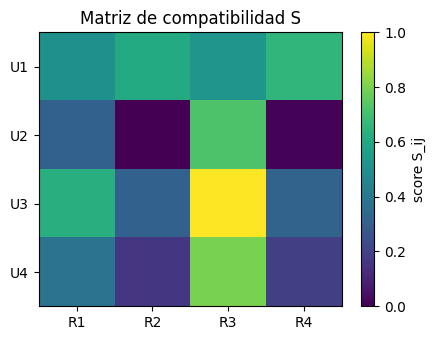

In [ ]:
assert len(A_df) == 4, "A_df debe tener exactamente 4 filas."
assert len(B_df) == 4, "B_df debe tener exactamente 4 filas."
assert S.shape == (4, 4), "S debe tener forma (4, 4)."
assert np.isfinite(S).all(), "S contiene valores no finitos (NaN o inf)."

print("✓ Dataset validado: forma compatible con matching 4×4.")

plt.figure(figsize=(4.5, 3.5))
plt.imshow(S, aspect="auto")
plt.xticks(range(N_B), B_df.index)
plt.yticks(range(N_A), A_df.index)
plt.colorbar(label="score S_ij")
plt.title("Matriz de compatibilidad S")
plt.tight_layout()
plt.show()

## 4. Variables binarias $x_{ij}$

Cada posible par (usuario $i$, ruta $j$) se convierte en una variable binaria $x_{ij} \in \{0,1\}$.

La función `var_index(i, j)` las aplana en un vector de 16 elementos:

$$
k = i \cdot N_B + j \quad \Rightarrow \quad k \in \{0, 1, \ldots, 15\}
$$

Por ejemplo:
- $(i=0, j=0) \to k=0$ → par (U1, R1)
- $(i=1, j=2) \to k=6$ → par (U2, R3)
- $(i=3, j=3) \to k=15$ → par (U4, R4)

In [ ]:
def var_index(i: int, j: int, n_b: int = N_B) -> int:
    return i * n_b + j

variables = []
for i, a_id in enumerate(A_df.index):
    for j, b_id in enumerate(B_df.index):
        variables.append({
            "k": var_index(i, j),
            "variable": f"x_{a_id}_{b_id}",
            "A": a_id,
            "B": b_id,
            "score S_ij": S[i, j],
        })

variables_df = pd.DataFrame(variables).set_index("k")
display(variables_df)

,variable,A,B,score S_ij
k,,,,
0,x_U1_R1,U1,R1,0.50
1,x_U1_R2,U1,R2,0.61
2,x_U1_R3,U1,R3,0.52
3,x_U1_R4,U1,R4,0.66
4,x_U2_R1,U2,R1,0.31
5,x_U2_R2,U2,R2,0.00
6,x_U2_R3,U2,R3,0.72
7,x_U2_R4,U2,R4,0.01
8,x_U3_R1,U3,R1,0.63


## 5. Penalización $\lambda$

El QUBO minimiza. Para convertir el problema de maximización de score en minimización,
se usa el término $-S_{ij} x_{ij}$ (signo negativo).

Las restricciones (cada usuario en exactamente una ruta, cada ruta con exactamente un usuario)
se añaden como penalizaciones cuadráticas con parámetro $\lambda$:

$$
\text{penalización por fila } i = \lambda \left(\sum_j x_{ij} - 1\right)^2
$$

Para garantizar que nunca convenga violar una restricción, $\lambda$ debe ser mayor
que el mayor score posible. La regla conservadora usada aquí es:

$$
\lambda = \lceil 4 \cdot \max|S_{ij}| + 1 \rceil
$$

In [ ]:
def choose_penalty(score_matrix: np.ndarray) -> float:
    max_abs_score = float(np.max(np.abs(score_matrix)))
    return float(math.ceil(4.0 * max_abs_score + 1.0))

LAMBDA_A = choose_penalty(S)
LAMBDA_B = choose_penalty(S)

print("λ_A =", LAMBDA_A)
print("λ_B =", LAMBDA_B)

λ_A = 5.0
λ_B = 5.0


## 6. Construcción de la matriz QUBO

La energía del sistema para una configuración $x \in \{0,1\}^{16}$ es:

$$
E(x) = \sum_k Q_{kk}\, x_k + \sum_{k < \ell} Q_{k\ell}\, x_k x_\ell + \text{offset}
$$

La función `add_exactly_one_penalty` agrega la penalización $\lambda(\sum_k x_k - 1)^2$
al QUBO. Al expandir ese cuadrado y usar el truco $x_k^2 = x_k$ para bits, se obtiene:

$$
\lambda\!\left(\sum_k x_k - 1\right)^2
= \lambda\!\left(-\sum_k x_k + 2\sum_{k<\ell} x_k x_\ell + 1\right)
$$

Lo que produce:
- $Q_{kk} \mathrel{+}= -\lambda$ para cada $k$ del grupo (término diagonal)
- $Q_{k\ell} \mathrel{+}= +2\lambda$ para cada par único $k < \ell$ del grupo (triangular superior)
- offset $\mathrel{+}= +\lambda$ (constante)

Solo se llena la triangular superior porque la fórmula de energía ya cuenta cada par $(k,\ell)$ una sola vez.

In [ ]:
def add_exactly_one_penalty(Q: np.ndarray, group: list, penalty: float) -> float:
    """Agrega lambda*(sum(group)-1)^2 a Q. Devuelve el offset (la constante +lambda)."""
    offset = float(penalty)
    for k in group:
        Q[k, k] += -penalty                     # término diagonal: -lambda
    for pos, k in enumerate(group):
        for l in group[pos + 1:]:               # solo triangular superior: k < l
            Q[k, l] += 2.0 * penalty            # término cuadrático: +2*lambda
    return offset

In [ ]:
def build_assignment_qubo(score_matrix: np.ndarray, lambda_a: float, lambda_b: float):
    """
    Construye la matriz Q y el offset para el problema de asignación 4x4.

    El QUBO combina tres contribuciones:
      1. Objetivo: Q[k,k] -= S[i,j]  (minimizar score negativo = maximizar score)
      2. Restricción por filas:  lambda*(sum_j x_ij - 1)^2  para cada usuario i
      3. Restricción por columnas: lambda*(sum_i x_ij - 1)^2  para cada ruta j
    """
    S_local = np.asarray(score_matrix, dtype=float)
    n_a, n_b = S_local.shape
    Q = np.zeros((n_a * n_b, n_a * n_b), dtype=float)
    offset = 0.0

    # 1. Objetivo
    for i in range(n_a):
        for j in range(n_b):
            k = var_index(i, j, n_b)
            Q[k, k] += -S_local[i, j]

    # 2. Restricciones por filas (un grupo por usuario)
    for i in range(n_a):
        group = [var_index(i, j, n_b) for j in range(n_b)]
        offset += add_exactly_one_penalty(Q, group, lambda_a)

    # 3. Restricciones por columnas (un grupo por ruta)
    for j in range(n_b):
        group = [var_index(i, j, n_b) for i in range(n_a)]
        offset += add_exactly_one_penalty(Q, group, lambda_b)

    return Q, float(offset)

Q, qubo_offset = build_assignment_qubo(S, LAMBDA_A, LAMBDA_B)

print("Variables binarias:", N_VARS)
print("Offset QUBO:", qubo_offset)
print("Términos no nulos en Q:", int(np.count_nonzero(np.abs(Q) > 1e-12)))

Variables binarias: 16
Offset QUBO: 40.0
Términos no nulos en Q: 64


## 7. Funciones de evaluación e interpretación

Para analizar cualquier configuración $x \in \{0,1\}^{16}$:

- `qubo_energy(x)`: calcula $E(x) = \sum_k Q_{kk} x_k + \sum_{k<\ell} Q_{k\ell} x_k x_\ell + \text{offset}$
- `assignment_matrix(x)`: convierte el vector de 16 bits en la matriz $4 \times 4$ de asignación
- `is_feasible(x)`: verifica que cada fila sume 1 y cada columna sume 1
- `assignment_score(x)`: calcula el score total de la asignación $\sum_{ij} S_{ij} x_{ij}$
- `selected_pairs(x)`: tabla legible con los 4 pares activos y sus scores

In [ ]:
def qubo_energy(x: np.ndarray, Q: np.ndarray, offset: float = 0.0) -> float:
    x = np.asarray(x, dtype=int)
    energy = float(offset)
    for k in range(len(x)):
        energy += Q[k, k] * x[k]
    for k in range(len(x)):
        for l in range(k + 1, len(x)):
            energy += Q[k, l] * x[k] * x[l]
    return float(energy)

def assignment_matrix(x: np.ndarray) -> np.ndarray:
    return np.asarray(x, dtype=int).reshape(N_A, N_B)

def is_feasible(x: np.ndarray) -> bool:
    M = assignment_matrix(x)
    return bool((M.sum(axis=1) == 1).all() and (M.sum(axis=0) == 1).all())

def assignment_score(x: np.ndarray, score_matrix: np.ndarray = None) -> float:
    sm = S if score_matrix is None else score_matrix
    return float(np.sum(assignment_matrix(x) * sm))

def selected_pairs(x: np.ndarray) -> pd.DataFrame:
    M = assignment_matrix(x)
    rows = []
    for i, a_id in enumerate(A_df.index):
        for j, b_id in enumerate(B_df.index):
            if M[i, j] == 1:
                rows.append({"A": a_id, "B": b_id, "score": S[i, j]})
    return pd.DataFrame(rows)

## 8. Convención de bitstrings

Qiskit representa los bitstrings en orden inverso al del vector $x$ interno.
Estas funciones de conversión garantizan que los resultados del muestreo local
y los del hardware real sean comparables entre sí.

In [ ]:
def x_to_qiskit_bitstring(x: np.ndarray) -> str:
    x = np.asarray(x, dtype=int)
    return "".join(str(int(bit)) for bit in x[::-1])

def index_to_qiskit_bitstring(index: int, n_bits: int = N_VARS) -> str:
    return format(int(index), f"0{n_bits}b")

def decode_qiskit_bitstring(bitstring: str, n_bits: int = N_VARS) -> np.ndarray:
    clean = str(bitstring).replace(" ", "").strip()
    if clean.startswith("0b"):
        clean = clean[2:]
    clean = clean.zfill(n_bits)[-n_bits:]
    return np.array([int(bit) for bit in clean[::-1]], dtype=int)

def normalizar_conteos(counts, n_bits: int = N_VARS):
    if counts is None:
        return None
    normalized = {}
    for key, value in counts.items():
        if value is None:
            continue
        if isinstance(key, (int, np.integer)):
            bitstring = index_to_qiskit_bitstring(int(key), n_bits)
        else:
            bitstring = str(key).replace(" ", "").strip()
            if bitstring.startswith("0b"):
                bitstring = bitstring[2:]
            bitstring = bitstring.zfill(n_bits)[-n_bits:]
        normalized[bitstring] = normalized.get(bitstring, 0) + int(value)
    return normalized

## 9. Solución exacta clásica por fuerza bruta

Se generan las $2^{16} = 65\,536$ configuraciones binarias posibles y se calcula
la energía QUBO de cada una. La de menor energía es la **solución óptima exacta**.

Esta operación es factible porque 65,536 es un número pequeño para una CPU moderna.
Para $N > 6$ usuarios/rutas, el espacio de búsqueda sería $2^{N^2}$, lo que hace
la fuerza bruta inviable y justifica el uso de algoritmos cuánticos.

In [ ]:
def all_binary_vectors(n_bits: int) -> np.ndarray:
    integers = np.arange(2 ** n_bits, dtype=np.uint32)
    return ((integers[:, None] >> np.arange(n_bits)) & 1).astype(np.int8)

all_x = all_binary_vectors(N_VARS)
print("Configuraciones totales:", len(all_x))
print("Memoria en MB:", round(all_x.nbytes / 1024**2, 3))

Configuraciones totales: 65536
Memoria en MB: 1.0


In [ ]:
def qubo_energy_many(X: np.ndarray, Q: np.ndarray, offset: float = 0.0) -> np.ndarray:
    """Calcula la energía QUBO de todas las configuraciones en paralelo (vectorizado)."""
    X = np.asarray(X, dtype=float)
    energies = np.full(X.shape[0], float(offset), dtype=float)
    for k in range(Q.shape[0]):
        energies += Q[k, k] * X[:, k]
    for k in range(Q.shape[0]):
        for l in range(k + 1, Q.shape[0]):
            if abs(Q[k, l]) > 1e-12:
                energies += Q[k, l] * X[:, k] * X[:, l]
    return energies

energy_by_state = qubo_energy_many(all_x, Q, qubo_offset)
best_state_index = int(np.argmin(energy_by_state))
best_x_exact = all_x[best_state_index]

In [ ]:
best_energy_exact  = float(energy_by_state[best_state_index])
best_score_exact   = assignment_score(best_x_exact)
best_feasible_exact = is_feasible(best_x_exact)

print("Mejor energía QUBO exacta :", best_energy_exact)
print("Score de la mejor solución:", best_score_exact)
print("¿La mejor solución es factible?:", best_feasible_exact)
print()
display(pd.DataFrame(assignment_matrix(best_x_exact), index=A_df.index, columns=B_df.index))
display(selected_pairs(best_x_exact))

Mejor energía QUBO exacta : -2.169999999999998
Score de la mejor solución: 2.17
¿La mejor solución es factible?: True



id,R1,R2,R3,R4
id,,,,
U1,0,0,0,1
U2,0,0,1,0
U3,1,0,0,0
U4,0,1,0,0


,A,B,score
0,U1,R4,0.66
1,U2,R3,0.72
2,U3,R1,0.63
3,U4,R2,0.16


## 10. Verificación por permutaciones factibles

Las únicas asignaciones que satisfacen ambas restricciones son las $4! = 24$ permutaciones
posibles (bijecciones de $A$ en $B$). Se evalúan las 24 y se compara la mejor contra
el resultado de fuerza bruta.

Si coinciden, el QUBO está bien construido. Si no coinciden, la penalización $\lambda$ es muy pequeña.

In [ ]:
best_perm = None
best_perm_score = -np.inf

for perm in permutations(range(N_B)):
    score = sum(S[i, perm[i]] for i in range(N_A))
    if score > best_perm_score:
        best_perm_score = float(score)
        best_perm = perm

x_perm = np.zeros(N_VARS, dtype=int)
for i, j in enumerate(best_perm):
    x_perm[var_index(i, j)] = 1

print("Mejor score por permutaciones:", best_perm_score)
print("Energía QUBO de esa asignación:", qubo_energy(x_perm, Q, qubo_offset))
print("¿Coincide con el óptimo QUBO?:", np.array_equal(x_perm, best_x_exact))
print()
display(pd.DataFrame(assignment_matrix(x_perm), index=A_df.index, columns=B_df.index))

Mejor score por permutaciones: 2.17
Energía QUBO de esa asignación: -2.169999999999998
¿Coincide con el óptimo QUBO?: True



id,R1,R2,R3,R4
id,,,,
U1,0,0,0,1
U2,0,0,1,0
U3,1,0,0,0
U4,0,1,0,0


## 11. Estado inicial de QAOA y vector de energías

QAOA comienza en el estado cuántico uniforme (superposición de todos los estados):

$$
|+\rangle^{\otimes n} = \frac{1}{\sqrt{2^n}} \sum_{x \in \{0,1\}^n} |x\rangle
$$

En la simulación vectorial, este estado se representa como un vector de $2^{16} = 65\,536$
amplitudes complejas, todas iguales a $1/\sqrt{65536}$.

El vector de energías `phase_energy` es la versión normalizada de `energy_by_state`.
La normalización (restar la media y dividir entre la desviación estándar) mejora
la estabilidad numérica al calcular las fases del circuito.

In [ ]:
N_STATES = 2 ** N_VARS

energy_center = float(np.mean(energy_by_state))
energy_scale  = float(np.std(energy_by_state))
if energy_scale == 0:
    energy_scale = 1.0

phase_energy = (energy_by_state - energy_center) / energy_scale

print("Estados totales:", N_STATES)
print("Memoria del vector de estado (MB):",
      round((N_STATES * np.dtype(np.complex128).itemsize) / 1024**2, 3))
print("Escala de energías:", round(energy_scale, 4))

def plus_state(n_bits: int) -> np.ndarray:
    return np.ones(2 ** n_bits, dtype=np.complex128) / math.sqrt(2 ** n_bits)

def apply_cost_phase(state: np.ndarray, gamma: float) -> np.ndarray:
    """Aplica U_C(gamma) = exp(-i*gamma*H_C). Multiplica cada amplitud por e^(-i*gamma*E)."""
    return state * np.exp(-1j * gamma * phase_energy)

Estados totales: 65536
Memoria del vector de estado (MB): 1.0
Escala de energías: 42.7773


## 12. Mixer estándar $U_M(\beta)$

El mixer aplica una rotación en $X$ a cada qubit:

$$
U_M(\beta) = \exp\!\left(-i\beta \sum_k X_k\right)
= \bigotimes_{k=0}^{n-1} e^{-i\beta X_k}
$$

Para cada qubit $k$, la operación intercambia y mezcla las amplitudes de los pares
de estados que difieren únicamente en el bit $k$:

$$
\begin{pmatrix} a' \\ b' \end{pmatrix}
= \begin{pmatrix} \cos\beta & -i\sin\beta \\ -i\sin\beta & \cos\beta \end{pmatrix}
\begin{pmatrix} a \\ b \end{pmatrix}
$$

**Nota:** este mixer estándar no preserva la factibilidad. Por eso mediremos
la probabilidad de factibilidad como métrica de calidad después del muestreo.

In [ ]:
def apply_mixer(state: np.ndarray, beta: float, n_bits: int) -> np.ndarray:
    """Aplica U_M(beta) eficientemente sin construir matrices de 65536x65536."""
    state = state.copy()
    c = math.cos(beta)
    s = -1j * math.sin(beta)

    for k in range(n_bits):
        step  = 1 << k        # 2^k
        block = step << 1     # 2^(k+1)
        view  = state.reshape(-1, block)

        left  = view[:, :step].copy()   # amplitudes con bit k = 0
        right = view[:, step:block].copy()  # amplitudes con bit k = 1

        view[:, :step]      = c * left  + s * right
        view[:, step:block] = s * left  + c * right

    return state

## 13. Circuito QAOA con $p=1$

Para $p=1$, el circuito tiene exactamente dos parámetros $(\gamma, \beta)$:

$$
|\psi(\gamma,\beta)\rangle = U_M(\beta)\, U_C(\gamma)\, |+\rangle^{\otimes n}
$$

La función `qaoa_expected_energy` calcula el valor esperado de la energía bajo
esa distribución cuántica:

$$
\langle E \rangle = \sum_x |\langle x | \psi(\gamma,\beta)\rangle|^2 \cdot E(x)
$$

Esta es la cantidad que el optimizador clásico (COBYLA) va a minimizar.

In [ ]:
QAOA_P = 1  # número de capas (p); aumentar mejora la calidad pero aumenta el tiempo

def qaoa_state(params: np.ndarray, p: int = QAOA_P) -> np.ndarray:
    params = np.asarray(params, dtype=float)
    state  = plus_state(N_VARS)
    for layer in range(p):
        gamma = params[2 * layer]
        beta  = params[2 * layer + 1]
        state = apply_cost_phase(state, gamma)
        state = apply_mixer(state, beta, N_VARS)
    return state

def qaoa_expected_energy(params: np.ndarray) -> float:
    state = qaoa_state(params, QAOA_P)
    probs = np.abs(state) ** 2
    return float(np.dot(probs, energy_by_state))

## 14. Optimización clásica de parámetros (COBYLA)

COBYLA es un optimizador sin gradiente que busca los valores de $(\gamma, \beta)$
que minimizan $\langle E(\gamma, \beta) \rangle$.

Con `N_RESTARTS = 1` y `MAXITER = 25` la ejecución es rápida en Colab.
La brecha entre la energía esperada de QAOA y el óptimo clásico exacto indica
cuánto le falta al circuito (con $p=1$) para concentrar la probabilidad en el óptimo.

In [ ]:
N_RESTARTS = 1
MAXITER    = 25

best_result = None

for restart in range(N_RESTARTS):
    initial = rng.uniform(low=-np.pi, high=np.pi, size=2 * QAOA_P)
    result  = minimize(
        qaoa_expected_energy,
        initial,
        method="COBYLA",
        options={"maxiter": MAXITER, "rhobeg": 0.7, "disp": False},
    )
    if best_result is None or result.fun < best_result.fun:
        best_result = result

best_params          = np.asarray(best_result.x, dtype=float)
best_expected_energy = float(best_result.fun)

print("Mejores parámetros QAOA:", np.round(best_params, 6))
print("Energía esperada QAOA  :", round(best_expected_energy, 6))
print("Óptimo clásico exacto  :", round(best_energy_exact, 6))
print("Brecha                 :", round(best_expected_energy - best_energy_exact, 6))

Mejores parámetros QAOA: [-1.767436  0.438172]
Energía esperada QAOA  : 17.343029
Óptimo clásico exacto  : -2.17
Brecha                 : 19.513029


## 15. Muestreo local

Con los parámetros óptimos $(\gamma^*, \beta^*)$ se construye el estado final
$|\psi(\gamma^*, \beta^*)\rangle$ y se obtiene la distribución de probabilidad:

$$
p(x) = |\langle x | \psi(\gamma^*, \beta^*)\rangle|^2
$$

Se simulan **2,000 mediciones** sorteando estados según $p(x)$.
El mejor bitstring observado (el de menor energía QUBO) es el resultado reportado de QAOA.

In [ ]:
qaoa_final_state = qaoa_state(best_params, QAOA_P)
qaoa_probs       = np.abs(qaoa_final_state) ** 2
qaoa_probs      /= qaoa_probs.sum()   # renormalizar por errores de punto flotante

SHOTS_LOCAL    = 2000
sampled_indices = rng.choice(N_STATES, size=SHOTS_LOCAL, replace=True, p=qaoa_probs)

sample_counts  = Counter(sampled_indices)
counts_local   = Counter(index_to_qiskit_bitstring(int(idx), N_VARS)
                         for idx in sampled_indices)

observed_indices     = np.array(list(sample_counts.keys()), dtype=int)
best_observed_index  = int(observed_indices[np.argmin(energy_by_state[observed_indices])])
best_x_qaoa          = all_x[best_observed_index]

print("Shots simulados         :", SHOTS_LOCAL)
print("Bitstrings distintos    :", len(sample_counts))
print("Mejor energía observada :", float(energy_by_state[best_observed_index]))
print("Score de la mejor muestra:", assignment_score(best_x_qaoa))
print("¿Factible?              :", is_feasible(best_x_qaoa))
print()
display(pd.DataFrame(assignment_matrix(best_x_qaoa), index=A_df.index, columns=B_df.index))
display(selected_pairs(best_x_qaoa))

Shots simulados         : 2000
Bitstrings distintos    : 1534
Mejor energía observada : -2.169999999999998
Score de la mejor muestra: 2.17
¿Factible?              : True



id,R1,R2,R3,R4
id,,,,
U1,0,0,0,1
U2,0,0,1,0
U3,1,0,0,0
U4,0,1,0,0


,A,B,score
0,U1,R4,0.66
1,U2,R3,0.72
2,U3,R1,0.63
3,U4,R2,0.16


## 16. Métricas probabilísticas de QAOA

Se calculan sobre la distribución ideal $p(x)$ (no sobre las muestras):

- **P(factible)**: suma de $p(x)$ sobre todos los estados que cumplen ambas restricciones.
  Indica qué fracción de las mediciones esperadas produce una asignación válida.

- **P(óptimo)**: $p(x^*)$ donde $x^*$ es el óptimo clásico exacto.
  Indica con qué frecuencia ideal aparecería la mejor solución al medir.

In [ ]:
assignments_3d = all_x.reshape(N_STATES, N_A, N_B)
row_ok     = (assignments_3d.sum(axis=2) == 1).all(axis=1)
col_ok     = (assignments_3d.sum(axis=1) == 1).all(axis=1)
feasible_mask = row_ok & col_ok

prob_feasible       = float(qaoa_probs[feasible_mask].sum())
prob_exact_optimum  = float(qaoa_probs[best_state_index])

print("P(solución factible)      :", round(prob_feasible, 6))
print("P(óptimo clásico exacto)  :", round(prob_exact_optimum, 6))

P(solución factible)      : 0.023419
P(óptimo clásico exacto)  : 0.00099


## 17. Distribución de energías muestreadas

El histograma muestra qué energías aparecieron en las 2,000 mediciones simuladas.
La línea discontinua marca el óptimo clásico exacto.
Una buena distribución QAOA concentra la masa en energías cercanas al óptimo.

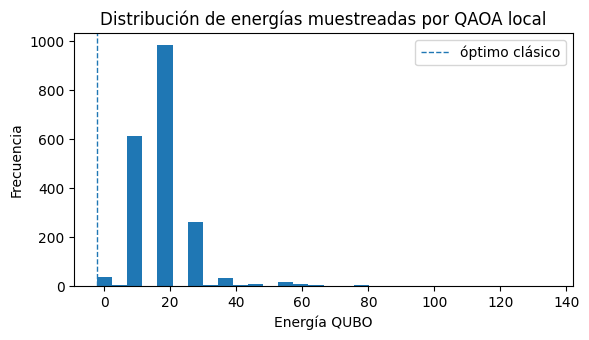

In [ ]:
sampled_energies = energy_by_state[sampled_indices]

plt.figure(figsize=(6, 3.5))
plt.hist(sampled_energies, bins=30)
plt.axvline(best_energy_exact, linestyle="--", linewidth=1, label="óptimo clásico")
plt.xlabel("Energía QUBO")
plt.ylabel("Frecuencia")
plt.title("Distribución de energías muestreadas por QAOA local")
plt.legend()
plt.tight_layout()
plt.show()

## 18. Comparación final: clásico exacto vs QAOA local

Esta tabla y gráfica son las que se reportan en el README del proyecto.

,método,energía QUBO,score total,factible,P(factible),P(óptimo clásico)
0,Clásico exacto,-2.17,2.17,True,NaN,NaN
1,QAOA local (mejor muestra),-2.17,2.17,True,0.023419,0.00099


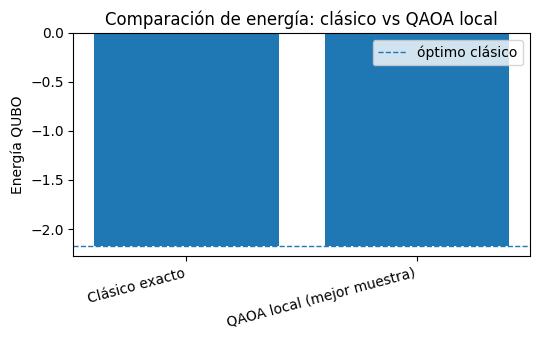

In [ ]:
comparison_df = pd.DataFrame([
    {
        "método"               : "Clásico exacto",
        "energía QUBO"         : best_energy_exact,
        "score total"          : best_score_exact,
        "factible"             : best_feasible_exact,
        "P(factible)"          : float("nan"),
        "P(óptimo clásico)"    : float("nan"),
    },
    {
        "método"               : "QAOA local (mejor muestra)",
        "energía QUBO"         : float(energy_by_state[best_observed_index]),
        "score total"          : assignment_score(best_x_qaoa),
        "factible"             : is_feasible(best_x_qaoa),
        "P(factible)"          : prob_feasible,
        "P(óptimo clásico)"    : prob_exact_optimum,
    },
])

display(comparison_df)

plt.figure(figsize=(5.5, 3.5))
plt.bar(comparison_df["método"], comparison_df["energía QUBO"])
plt.axhline(best_energy_exact, linestyle="--", linewidth=1, label="óptimo clásico")
plt.ylabel("Energía QUBO")
plt.title("Comparación de energía: clásico vs QAOA local")
plt.xticks(rotation=15, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## 19. Resumen automático

Imprime un resumen compacto de todos los resultados, listo para copiar al README.

In [ ]:
print("=" * 55)
print("RESUMEN DEL PROYECTO")
print("=" * 55)
print(f"Instancia        : {NOMBRE_INSTANCIA}")
print(f"Tamaño           : {len(A_df)} x {len(B_df)}")
print(f"Variables QUBO   : {N_VARS}")
print(f"Lambda           : {LAMBDA_A}")
print()
print("── Solución clásica exacta ──")
print(f"  Energía QUBO   : {best_energy_exact}")
print(f"  Score total    : {best_score_exact}")
print(f"  Factible       : {best_feasible_exact}")
display(selected_pairs(best_x_exact))
print()
print("── QAOA local (p=1, COBYLA) ──")
print(f"  Parámetros     : gamma={round(best_params[0],4)}, beta={round(best_params[1],4)}")
print(f"  Energía esperada: {round(best_expected_energy, 4)}")
print(f"  Brecha         : {round(best_expected_energy - best_energy_exact, 4)}")
print(f"  Mejor muestra  : energía={round(float(energy_by_state[best_observed_index]),4)}")
print(f"  P(factible)    : {round(prob_feasible, 4)}")
print(f"  P(óptimo)      : {round(prob_exact_optimum, 4)}")
display(selected_pairs(best_x_qaoa))
print("=" * 55)

RESUMEN DEL PROYECTO
Instancia        : dataset_real_4x4.csv
Tamaño           : 4 x 4
Variables QUBO   : 16
Lambda           : 5.0

── Solución clásica exacta ──
  Energía QUBO   : -2.169999999999998
  Score total    : 2.17
  Factible       : True


,A,B,score
0,U1,R4,0.66
1,U2,R3,0.72
2,U3,R1,0.63
3,U4,R2,0.16



── QAOA local (p=1, COBYLA) ──
  Parámetros     : gamma=-1.7674, beta=0.4382
  Energía esperada: 17.343
  Brecha         : 19.513
  Mejor muestra  : energía=-2.17
  P(factible)    : 0.0234
  P(óptimo)      : 0.001


,A,B,score
0,U1,R4,0.66
1,U2,R3,0.72
2,U3,R1,0.63
3,U4,R2,0.16
